# 01ZLMA - Exercise 02

Exercise 02 of the course [01ZLMA](https://math.fel.cvut.cz/en/people/francji1/01ZLMA.html) - Generalized Linear Models.

## Contents

1. [Theory Recap from Lectures 01-03](#1-theory-recap-from-lectures-01-03)
   - 1.1 [Regularity Conditions](#11-regularity-conditions)
   - 1.2 [GLM Definition](#12-glm-definition)
   - 1.3 [Exponential Family](#13-exponential-family---detailed-table)
   - 1.4 [Relations $\beta \to \eta \to \mu \to \theta$](#14-relations)
   - 1.5 [Likelihood, Score, Fisher Information](#15-likelihood-score-function-fisher-information-matrix)
2. [Bernoulli Example: Score & Fisher Information](#2-bernoulli-example-score--fisher-information)
3. [MLE for GLM Parameters](#3-mle-for-glm-parameters)
   - 3.1 [Likelihood Equations for GLM](#31-likelihood-equations-for-glm)
   - 3.2 [Canonical Link Simplifications](#32-canonical-link-simplifications)
4. [Numerical Methods for MLE](#4-numerical-methods-for-mle)
   - 4.1 [Newton-Raphson](#41-newton-raphson)
   - 4.2 [Fisher Scoring](#42-fisher-scoring)
   - 4.3 [IWLS](#43-iteratively-weighted-least-squares-iwls)
   - 4.4 [Initial Values & Convergence](#44-initial-values--convergence-criteria)
5. [Example 1: Poisson with Identity Link (Dobson 4.4)](#5-example-1-poisson-with-identity-link-dobson-44)
6. [Example 2: Poisson with Log Link (AIDS data, Dobson 4.1)](#6-example-2-poisson-with-log-link-aids-data-dobson-41)
7. [Example 3: Gamma Regression](#7-example-3-gamma-regression)
8. [Example 4: Bernoulli / Logistic Regression (preview)](#8-example-4-bernoulli--logistic-regression-preview)
9. [Dispersion Parameter Estimation](#9-dispersion-parameter-estimation)
10. [Summary: Comparison of Methods & Distributions](#10-summary-comparison-of-methods--distributions)
11. [Homework](#11-homework)

---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import gammaln
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson, Gamma, Binomial
from statsmodels.genmod.families.links import Identity, Log, InversePower, Logit
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=6, suppress=True)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

---
# 1. Theory Recap from Lectures 01-03

## 1.1 Regularity Conditions

Let $(\mathcal{Y},\,\mathcal{B},\,P_\theta)_{\theta\in\Theta}$ be a parametric family of probability spaces, where  
$\mathcal{Y} \subset \mathbb{R}$ is a sample space,  
$\mathcal{B}$ is a Borel $\sigma$-algebra of subsets of $\mathcal{Y}$,  
$\Theta \subset \mathbb{R}^m$ is a parametric space.

Assume $f(y;\,\theta)$ is a probability density function with respect to a $\sigma$-finite measure $\mu$  
(*Lebesgue measure in the continuous case and counting measure in the discrete case*), satisfying:

**(M1)** The set $A = \{y \in \mathcal{Y} : f(y;\theta) > 0\}$ does not depend on $\theta$.

**(M2)** If $\theta_1 \neq \theta_2$, then
$$
\mu(\{y \in A : f(y;\theta_1) = f(y;\theta_2)\}) = 0.
$$

We consider densities that satisfy the following **regularity conditions**:

**(R1)** For every parameter $\theta_0 \in \Theta$, there exists a neighborhood $N(\theta_0) \subset \Theta$ in which, for almost every $y \in A$ (with respect to $\mu$), the following derivatives exist:
$$
\frac{\partial f(y;\theta)}{\partial \theta_p}, \quad
\frac{\partial^2 f(y;\theta)}{\partial \theta_p \partial \theta_q}, \quad
\frac{\partial^3 f(y;\theta)}{\partial \theta_p \partial \theta_q \partial \theta_r}, \quad p,q,r = 1,\dots,m,
$$
and they are continuous and finite.

**(R2)** There exist constants $0 < L < \infty$ and real-valued functions $F(y)$, $G(y)$, and $H(y)$ (possibly dependent on $\theta_0$), such that for $p,q,r = 1,\dots,m$, for almost every $y \in A$ and for all $\theta \in N(\theta_0)$ it holds:
$$
\left|\frac{\partial f(y;\theta)}{\partial \theta_p}\right| < F(y), \quad
\left|\frac{\partial^2 f(y;\theta)}{\partial \theta_p \partial \theta_q}\right| < G(y), \quad
\left|\frac{\partial^3 \ln f(y;\theta)}{\partial \theta_p \partial \theta_q \partial \theta_r}\right| < H(y),
$$
where $F$ and $G$ are $\mu$-integrable and
$$
\int_A H(y)f(y;\theta)\,d\mu(y) < L.
$$

**(R3)** Fisher information matrix $I(\theta)$ is finite and positive definite for all $\theta \in \Theta$.

## 1.2 GLM Definition

A **Generalized Linear Model** consists of three components:

1. **Random component:** Response variables $Y_1, \ldots, Y_n$ are independent with densities from an exponential family:
$$f(y_i;\theta_i,\phi) = \exp\left\{\frac{y_i \theta_i - b(\theta_i)}{a_i(\phi)} + c(y_i,\phi)\right\}$$
where regularity conditions are fulfilled, $a_i(\phi) > 0$, $\phi > 0$.

2. **Systematic component:** Parameter vector $\boldsymbol{\beta}$ and design matrix $X$, defining the linear predictor $\eta_i = \mathbf{x}_i^T \boldsymbol{\beta}$.

3. **Link function:** $g(\cdot)$, monotone and differentiable, such that:
$$\eta_i = g(\mu_i) = \mathbf{x}_i^T \boldsymbol{\beta}, \quad \text{where } \mu_i = E[Y_i]$$

The dispersion $a_i(\phi)$ is typically known. If not, we treat it as a nuisance parameter.

A link function satisfying $g(\mu_i) = \theta_i$ is called the **canonical link**.

## 1.3 Exponential Family - Detailed Table

For $b(\theta) \in C^2$ we showed:
$$E[Y] = b'(\theta), \qquad V[Y] = a(\phi)\, b''(\theta)$$

and defined the **variance function** $v(\mu) = \frac{\partial \mu}{\partial \theta} = b''(\theta)$, so that $V[Y] = a(\phi) \cdot v(\mu)$.

| Distribution | $\theta$ | $b(\theta)$ | $a(\phi)$ | $v(\mu)$ | Canonical link $g(\mu)$ |
|:---|:---:|:---:|:---:|:---:|:---:|
| Normal $N(\mu, \sigma^2)$ | $\mu$ | $\theta^2/2$ | $\sigma^2$ | $1$ | identity: $\mu$ |
| Poisson $\text{Poi}(\mu)$ | $\ln\mu$ | $e^\theta$ | $1$ | $\mu$ | log: $\ln\mu$ |
| Bernoulli $\text{Ber}(p)$ | $\ln\frac{\mu}{1-\mu}$ | $\ln(1+e^\theta)$ | $1$ | $\mu(1-\mu)$ | logit: $\ln\frac{\mu}{1-\mu}$ |
| Gamma $\Gamma(\nu,\mu)$ | $-1/\mu$ | $-\ln(-\theta)$ | $1/\nu$ | $\mu^2$ | reciprocal$^*$: $1/\mu$ |
| Inv. Gaussian $\text{IG}(\mu,\sigma^2)$ | $-1/(2\mu^2)$ | $-(-2\theta)^{1/2}$ | $\sigma^2$ | $\mu^3$ | $1/\mu^2$ $^*$ |

$^*$ **Sign convention note:** Strictly, the canonical link satisfies $g(\mu) = \theta$. For Gamma this gives $g(\mu) = -1/\mu$, and for inverse Gaussian $g(\mu) = -1/(2\mu^2)$. However, the standard convention in GLM theory (including this course, see Lecture 6), in R (`family = Gamma()` defaults to `link = "inverse"`, i.e. $1/\mu$), and in statsmodels is to call $g(\mu) = 1/\mu$ the canonical link for Gamma, absorbing the sign into the parameterization. The IWLS algorithm works correctly with this convention because the sign affects the direction of $\eta$ (and thus the signs of $\hat{\beta}$), but the fitted means $\hat{\mu}$ and the likelihood remain the same. We follow this standard convention throughout.

## 1.4 Relations

$$
\boldsymbol{\beta} \xrightarrow{\eta_i = \mathbf{x}_i^T\boldsymbol{\beta}} \boldsymbol{\eta}
\xrightarrow{\mu_i = g^{-1}(\eta_i)}  \boldsymbol{\mu}
\xrightarrow{\theta_i = (b')^{-1}(\mu_i)}  \boldsymbol{\theta}
$$

**Concrete examples:**

| | $\boldsymbol{\beta} \to \boldsymbol{\eta}$ | $\boldsymbol{\eta} \to \boldsymbol{\mu}$ | $\boldsymbol{\mu} \to \boldsymbol{\theta}$ |
|:---|:---|:---|:---|
| Poisson, log link | $\eta_i = \beta_1 + \beta_2 x_i$ | $\mu_i = e^{\eta_i}$ | $\theta_i = \ln\mu_i = \eta_i$ |
| Poisson, identity link | $\eta_i = \beta_1 + \beta_2 x_i$ | $\mu_i = \eta_i$ | $\theta_i = \ln\mu_i = \ln(\eta_i)$ |
| Bernoulli, logit link | $\eta_i = \beta_1 + \beta_2 x_i$ | $\mu_i = \frac{e^{\eta_i}}{1+e^{\eta_i}}$ | $\theta_i = \ln\frac{\mu_i}{1-\mu_i} = \eta_i$ |
| Gamma, reciprocal link | $\eta_i = \beta_1 + \beta_2 x_i$ | $\mu_i = 1/\eta_i$ | $\theta_i = -1/\mu_i = -\eta_i$ |

**Note:** For canonical links (Poisson log, Bernoulli logit), $\theta_i = \eta_i$, which greatly simplifies the likelihood equations (see Section 3.2). For Gamma with reciprocal link $g(\mu) = 1/\mu$, we have $\theta_i = -\eta_i$ (the sign differs from the strict $g(\mu) = \theta$ definition — see the sign convention note in Section 1.3). Despite this, the reciprocal link is conventionally called canonical for Gamma and the canonical-link corollaries still apply up to sign reparameterization.

## 1.5 Likelihood, Score Function, Fisher Information Matrix

(Under conditions M1, M2 and regularity conditions R1-R3 from the lecture)

**Likelihood function:**
$$L_n(\boldsymbol{\Theta}) = \prod_{i=1}^{n} f(y_i;\boldsymbol{\Theta})$$

**Log-likelihood function:**
$$l_n(\boldsymbol{\Theta}) = \sum_{i=1}^{n} \ln f(y_i;\boldsymbol{\Theta})$$

**Score function** (gradient of log-likelihood — direction of steepest ascent of $l$):
$$U = U(y; \boldsymbol{\Theta}) = \frac{\partial \ln f(y ; \boldsymbol{\Theta})}{\partial \boldsymbol{\Theta}}$$

**Key property:** $E_{\theta}[U] = 0$ (score has zero mean at the true parameter).

**Score vector** (for a sample):
$$\mathbf{U}_{n} = \sum_{i=1}^{n} U(y_i;\boldsymbol{\Theta}) = \sum_{i=1}^{n} \frac{\partial l_i(y_i ; \boldsymbol{\Theta})}{\partial \boldsymbol{\Theta}}$$

**Fisher Information matrix** (measures the curvature of $l$ — precision of estimation):
$$I_n(\boldsymbol{\Theta}) = E_{\theta}[\mathbf{U}_n \mathbf{U}_n^T]$$
with elements:
$$I_{n;j,k} = E_{\theta}\left[\frac{\partial l}{\partial \theta_j}\frac{\partial l}{\partial \theta_k}\right] = -E_{\theta}\left[\frac{\partial^2 l}{\partial\theta_j \partial\theta_k}\right]$$

**Interpretation:**
- $U > 0$ at current $\theta$ means: increasing $\theta$ would increase the likelihood — we should move $\theta$ upward.
- Large $I(\theta)$ means the log-likelihood is sharply curved — the data are very informative about $\theta$.
- The Cramér-Rao bound: $V[\hat{\theta}] \geq I_n(\theta)^{-1}$ — the inverse Fisher information is a lower bound on estimator variance.

---
# 2. Bernoulli Example: Score & Fisher Information

Consider $X_1, \ldots, X_n \stackrel{iid}{\sim} \text{Bernoulli}(p)$ with $p \in (0,1)$, and let $Y = \sum_{i=1}^n X_i$.

**Likelihood:**
$$L(p) = \prod_{i=1}^{n} p^{x_i}(1-p)^{1-x_i} = p^y(1-p)^{n-y}$$

**Log-likelihood:**
$$l(p) = y \ln p + (n-y) \ln(1-p)$$

**Score function:**
$$U(p) = \frac{\partial l}{\partial p} = \frac{y}{p} - \frac{n-y}{1-p}$$

**MLE:** Setting $U(\hat{p}) = 0$:
$$\hat{p}_{MLE} = \frac{y}{n}$$

**Fisher information:**
$$I(p) = -E\left[\frac{\partial^2 l}{\partial p^2}\right] = \frac{n}{p(1-p)}$$

**Interpretation of Score:**
- If $U(p) > 0$ at current $p$: the observed proportion $y/n$ exceeds $p$ — the MLE lies above the current value.
- $U(p) = 0$ exactly at $p = y/n$.

### Student Task: Bernoulli Score & Log-Likelihood

Simulate $n=9$ observations from $\text{Bernoulli}(0.4)$, compute $\hat{p}_{MLE}$, and plot:
1. Score $U(p;\, y)$ as a function of $y$ for fixed $p$ (how does the score change with observed count?)
2. Log-likelihood $l(p;\, y)$ as a function of $p$ for the observed $y$

In [2]:
# Simulation of Bernoulli distribution and computation of Score function
n = 9
p = 0.4
x = np.random.binomial(1, p, n)
y = np.sum(x)
p_hat = y / n
print(f"n = {n}, p = {p}, y = {y}, p_hat = {p_hat:.4f}")

# Define the score function U and the log-likelihood function l
def U(y_val, p=p, n=n):
    return  # fill

def l(p_val, y=y, n=n):
    return  # fill

n = 9, p = 0.4, y = 1, p_hat = 0.1111


**Solution:**

In [3]:
# Solution
def U(y_val, p=p, n=n):
    return y_val / p - (n - y_val) / (1 - p)

def l(p_val, y=y, n=n):
    return y * np.log(p_val) + (n - y) * np.log(1 - p_val)

# Fisher information
def fisher_info(p_val, n=n):
    return n / (p_val * (1 - p_val))

print(f"Score at p={p}: U = {U(y):.4f}")
print(f"Score at p_hat={p_hat:.4f}: U = {U(y, p=p_hat):.4f}")
print(f"Fisher information at p={p}: I(p) = {fisher_info(p):.4f}")
print(f"Fisher information at p_hat={p_hat:.4f}: I(p_hat) = {fisher_info(p_hat):.4f}")

Score at p=0.4: U = -10.8333
Score at p_hat=0.1111: U = 0.0000
Fisher information at p=0.4: I(p) = 37.5000
Fisher information at p_hat=0.1111: I(p_hat) = 91.1250


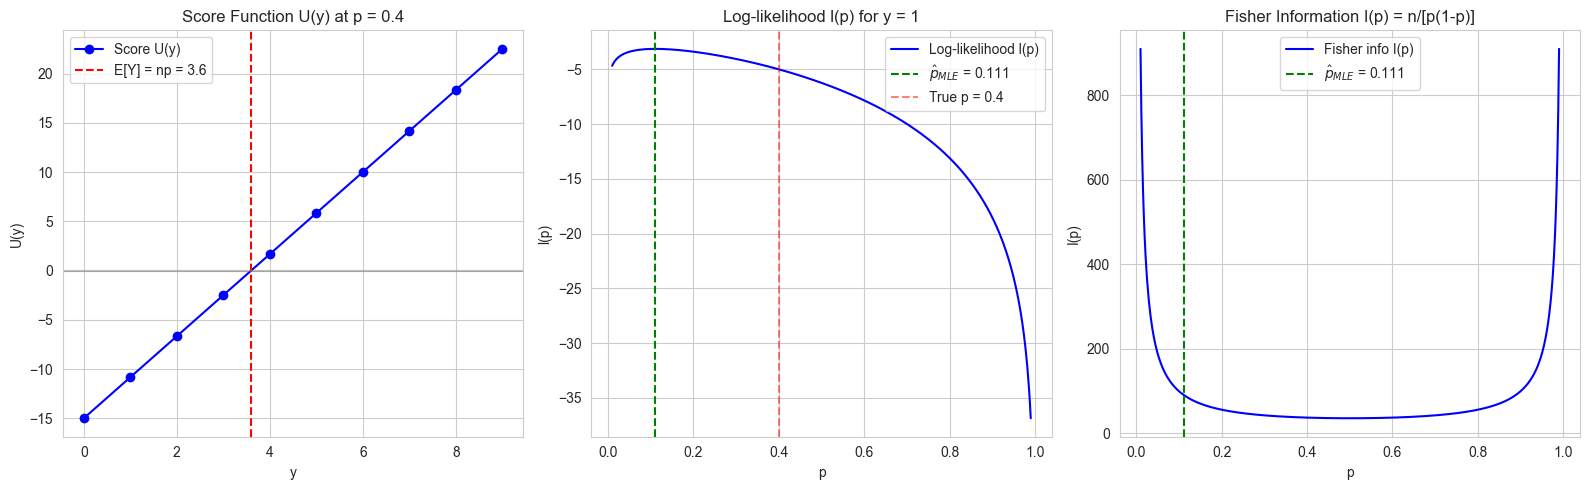

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Score function U(y) for fixed p
y_values = np.arange(0, n + 1)
U_values = [U(y_val) for y_val in y_values]
axes[0].plot(y_values, U_values, 'bo-', label='Score U(y)')
axes[0].axvline(x=n * p, color='red', linestyle='--', label=f'E[Y] = np = {n*p}')
axes[0].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[0].set_xlabel('y')
axes[0].set_ylabel('U(y)')
axes[0].set_title(f'Score Function U(y) at p = {p}')
axes[0].legend()

# 2. Log-likelihood l(p) for observed y
p_values = np.linspace(0.01, 0.99, 500)
l_values = [l(p_val) for p_val in p_values]
axes[1].plot(p_values, l_values, 'b-', label='Log-likelihood l(p)')
axes[1].axvline(x=p_hat, color='green', linestyle='--', label=f'$\hat{{p}}_{{MLE}}$ = {p_hat:.3f}')
axes[1].axvline(x=p, color='red', linestyle='--', alpha=0.5, label=f'True p = {p}')
axes[1].set_xlabel('p')
axes[1].set_ylabel('l(p)')
axes[1].set_title(f'Log-likelihood l(p) for y = {y}')
axes[1].legend()

# 3. Fisher information I(p)
I_values = [fisher_info(p_val) for p_val in p_values]
axes[2].plot(p_values, I_values, 'b-', label='Fisher info I(p)')
axes[2].axvline(x=p_hat, color='green', linestyle='--', label=f'$\hat{{p}}_{{MLE}}$ = {p_hat:.3f}')
axes[2].set_xlabel('p')
axes[2].set_ylabel('I(p)')
axes[2].set_title(f'Fisher Information I(p) = n/[p(1-p)]')
axes[2].legend()

plt.tight_layout()
plt.show()

---
# 3. MLE for GLM Parameters

## 3.1 Likelihood Equations for GLM

The log-likelihood for a GLM is:
$$l(\boldsymbol{\theta}, \phi, \mathbf{y}) = \sum_{i=1}^n \frac{y_i \theta_i - b(\theta_i)}{a_i(\phi)} + \sum_{i=1}^n c(y_i, \phi)$$

We want $\hat{\boldsymbol{\beta}} = \text{argmax}_{\boldsymbol{\beta}} \; l(\boldsymbol{\theta}, \phi, \mathbf{y})$.

**Derivation using the chain rule** $\beta \to \eta \to \mu \to \theta$:

$$\frac{\partial l}{\partial \beta_j} = \sum_{i=1}^n \frac{\partial l_i}{\partial \theta_i} \cdot \frac{\partial \theta_i}{\partial \mu_i} \cdot \frac{\partial \mu_i}{\partial \eta_i} \cdot \frac{\partial \eta_i}{\partial \beta_j}$$

where:
- $\frac{\partial l_i}{\partial \theta_i} = \frac{y_i - b'(\theta_i)}{a_i(\phi)} = \frac{y_i - \mu_i}{a_i(\phi)}$
- $\frac{\partial \theta_i}{\partial \mu_i} = \frac{1}{b''(\theta_i)} = \frac{1}{v(\mu_i)}$
- $\frac{\partial \mu_i}{\partial \eta_i} = \frac{1}{g'(\mu_i)}$
- $\frac{\partial \eta_i}{\partial \beta_j} = x_{ij}$

**Theorem 3.1.1 (Likelihood Equations):**

$$0 = U_j = \sum_{i=1}^n \frac{(y_i - \mu_i)\, x_{ij}}{a_i(\phi)\, v(\mu_i)\, g'(\mu_i)}, \quad j = 1, \ldots, p$$

In matrix form:
$$\mathbf{U}(\boldsymbol{\beta}) = X^T M^{-1}(\mathbf{y} - \boldsymbol{\mu}) = \mathbf{0}$$

where $M = \text{diag}(V[Y_i] \cdot g'(\mu_i)) = \text{diag}(a_i(\phi)\, v(\mu_i)\, g'(\mu_i))$.

**Alternative form (Proposition 3.1.2):**
$$\mathbf{U}(\boldsymbol{\beta}) = X^T W(\boldsymbol{\beta})^{-1} Z^*(\boldsymbol{\beta})$$

where:
- $W(\boldsymbol{\beta}) = \text{diag}\big(V[Y_i] \cdot g'(\mu_i)^2\big)$ — **weight matrix**
- $Z^*(\boldsymbol{\beta}) = \text{diag}\big(g'(\mu_i)\big)(\mathbf{y} - \boldsymbol{\mu})$ — **adjusted residuals**

**Fisher Information for GLM (Proposition 3.1.4):**
$$I(\boldsymbol{\beta}) = X^T W(\boldsymbol{\beta})^{-1} X$$

## 3.2 Canonical Link Simplifications

**Corollary 3.1.1:** If $g(\mu_i) = \theta_i$ (canonical link), the likelihood equations simplify to:
$$\sum_{i=1}^n \frac{(y_i - \mu_i)\, x_{ij}}{a_i(\phi)} = 0, \quad j = 1, \ldots, p$$

**Corollary 3.1.2:** If $a_i(\phi) = a_i \phi$ with known $a_i$, the likelihood equations **do not depend on $\phi$**.

**Corollary 3.1.3:** If both conditions hold (canonical link + $a_i(\phi) = a_i \phi$):
$$\sum_{i=1}^n \frac{(y_i - \mu_i)\, x_{ij}}{a_i} = 0$$

**Important consequence:** For Poisson with log link ($a_i = 1$), the likelihood equations become $X^T(\mathbf{y} - \boldsymbol{\mu}) = \mathbf{0}$, independent of $\phi$. The same applies to Bernoulli with logit link.

For canonical link, $\theta_i = \eta_i$, so $\frac{\partial \theta}{\partial \mu} \cdot \frac{\partial \mu}{\partial \eta} = 1$. This means:
- Newton-Raphson and Fisher Scoring give **identical** iterations (observed Hessian = expected Hessian).
- The weight matrix simplifies: $W = \text{diag}\big(v(\mu_i) \cdot g'(\mu_i)^2\big) = \text{diag}\big(1/v(\mu_i)\big)$ for $a_i(\phi) = 1$.

---
# 4. Numerical Methods for MLE

## 4.1 Newton-Raphson

$$\hat{\boldsymbol{\beta}}^{(r+1)} = \hat{\boldsymbol{\beta}}^{(r)} - H^{-1}(\hat{\boldsymbol{\beta}}^{(r)})\, \mathbf{U}(\hat{\boldsymbol{\beta}}^{(r)})$$

where $H(\boldsymbol{\beta}) = \left(\frac{\partial^2 l}{\partial \beta_j \partial \beta_k}\right)_{j,k=1,\ldots,p}$ is the **observed Hessian** matrix.

| Advantages | Disadvantages |
|:---|:---|
| Quadratic convergence near optimum | Hessian can be expensive to compute |
| Uses actual curvature | Can be unstable if Hessian is near-singular |
| | Requires good initial guess |

## 4.2 Fisher Scoring

$$\hat{\boldsymbol{\beta}}^{(r+1)} = \hat{\boldsymbol{\beta}}^{(r)} + I^{-1}(\hat{\boldsymbol{\beta}}^{(r)})\, \mathbf{U}(\hat{\boldsymbol{\beta}}^{(r)})$$

where $I(\boldsymbol{\beta}) = -E[H(\boldsymbol{\beta})] = X^T W(\boldsymbol{\beta})^{-1} X$.

Replaces the observed Hessian with its expectation (the Fisher information matrix).

| Advantages | Disadvantages |
|:---|:---|
| More numerically stable than NR | Typically linear convergence |
| $I(\boldsymbol{\beta})$ is always positive semi-definite | May need more iterations |
| For canonical link: identical to NR | |

**Key insight:** For canonical link, $H = -I$ exactly (not just in expectation), so NR $\equiv$ Fisher Scoring.

## 4.3 Iteratively Weighted Least Squares (IWLS)

Fisher Scoring can be rewritten as a sequence of weighted least squares problems.

Starting from:
$$I(\hat{\boldsymbol{\beta}}^{(r)})\, \hat{\boldsymbol{\beta}}^{(r+1)} = I(\hat{\boldsymbol{\beta}}^{(r)})\, \hat{\boldsymbol{\beta}}^{(r)} + \mathbf{U}(\hat{\boldsymbol{\beta}}^{(r)})$$

Substituting $I = X^T W^{-1} X$ and $\mathbf{U} = X^T W^{-1} Z^*$:

$$\boxed{\hat{\boldsymbol{\beta}}^{(r+1)} = \left(X^T W^{-1}(\hat{\boldsymbol{\beta}}^{(r)}) X\right)^{-1} X^T W^{-1}(\hat{\boldsymbol{\beta}}^{(r)})\, Z(\hat{\boldsymbol{\beta}}^{(r)})}$$

where the **working response** is:
$$Z(\boldsymbol{\beta}) = X\boldsymbol{\beta} + \text{diag}\big(g'(\mu_i)\big)(\mathbf{y} - \boldsymbol{\mu}) = \boldsymbol{\eta} + \text{diag}\big(g'(\mu_i)\big)(\mathbf{y} - \boldsymbol{\mu})$$

and $W(\boldsymbol{\beta}) = \text{diag}\big(V[Y_i] \cdot g'(\mu_i)^2\big)$.

Each IWLS step is a WLS regression of $Z$ on $X$ with weight matrix $W^{-1}$.

| Advantages | Disadvantages |
|:---|:---|
| Reduces to solving linear systems | Linear convergence (same as FS) |
| Numerically stable, easy to implement | Sensitive to poor initial guesses |
| Standard in GLM software | |

## 4.4 Initial Values & Convergence Criteria

**Initial values:** Choose $\hat{\boldsymbol{\mu}}^{(0)} = \mathbf{y}$ (or a slight perturbation if $g(y_i)$ is undefined), then:
$$\hat{\boldsymbol{\beta}}^{(0)} = (X^T X)^{-1} X^T g(\mathbf{y})$$
i.e., OLS regression of the link-transformed responses.

**Convergence criteria** (stop when any of these are met):
1. Relative change in $\boldsymbol{\beta}$: $\frac{\|\hat{\boldsymbol{\beta}}^{(r+1)} - \hat{\boldsymbol{\beta}}^{(r)}\|}{\|\hat{\boldsymbol{\beta}}^{(r)}\| + \epsilon} < \text{tol}$
2. Absolute change in log-likelihood: $|l^{(r+1)} - l^{(r)}| < \text{tol}$
3. Maximum number of iterations exceeded

---
# 5. Example 1: Poisson with Identity Link (Dobson 4.4)

Data from Dobson (2008), Example 4.4.

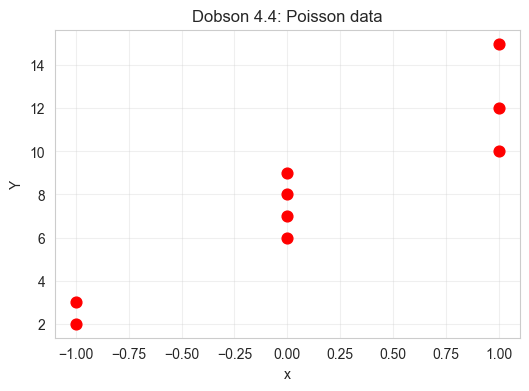

In [5]:
# Data
x_raw = np.array([-1, -1, 0, 0, 0, 0, 1, 1, 1])
Y1 = np.array([2, 3, 6, 7, 8, 9, 10, 12, 15])
n1 = len(x_raw)

plt.figure(figsize=(6, 4))
plt.scatter(x_raw, Y1, color='red', s=60, zorder=5)
plt.xlabel('x')
plt.ylabel('Y')
plt.title('Dobson 4.4: Poisson data')
plt.grid(True, alpha=0.3)
plt.show()

### Model specification

Assume $Y_i \sim \text{Poisson}(\mu_i)$ with **identity link**:
$$E[Y_i] = \mu_i = \beta_1 + \beta_2 x_i \quad \Rightarrow \quad g(\mu_i) = \mu_i, \quad g'(\mu_i) = 1$$

**Important constraint:** Since $Y_i \sim \text{Poisson}(\mu_i)$, we must have $\mu_i > 0$ for all $i$. With the identity link this is **not automatically guaranteed** — the linear predictor $\beta_1 + \beta_2 x_i$ can become non-positive for some parameter values. Initial values and iteration steps must be chosen to keep all $\mu_i > 0$.

**Weight matrix for Poisson with identity link:**
$$w_{ii} = V[Y_i] \cdot g'(\mu_i)^2 = \mu_i \cdot 1 = \mu_i = \beta_1 + \beta_2 x_i$$

So $W^{-1} = \text{diag}\left(\frac{1}{\mu_i}\right) = \text{diag}\left(\frac{1}{\beta_1 + \beta_2 x_i}\right)$.

**Working response for identity link:**
$$z_i = \eta_i + g'(\mu_i)(y_i - \mu_i) = \mu_i + 1 \cdot (y_i - \mu_i) = y_i$$

So $Z = \mathbf{y}$ — the working response equals the observed data for the identity link!

**IWLS update:**
$$\hat{\boldsymbol{\beta}}^{(r+1)} = (X^T W^{-1}(\hat{\boldsymbol{\beta}}^{(r)}) X)^{-1} X^T W^{-1}(\hat{\boldsymbol{\beta}}^{(r)}) \mathbf{y}$$

### Manual IWLS steps

In [6]:
# Design matrix with intercept
X1 = np.column_stack((np.ones(n1), x_raw))

# Weight function for Poisson with identity link: W_inv = diag(1/mu) = diag(1/(X@beta))
def calc_W_inv_identity(X, beta):
    mu = X @ beta
    return np.diag(1.0 / mu)

# Initial values
beta_0 = np.array([7.0, 5.0])
print(f"beta_0 = {beta_0}")

# Step 0 -> 1
W_inv = calc_W_inv_identity(X1, beta_0)
beta_1 = np.linalg.solve(X1.T @ W_inv @ X1, X1.T @ W_inv @ Y1)
print(f"beta_1 = {beta_1}")

# Step 1 -> 2
W_inv = calc_W_inv_identity(X1, beta_1)
var_cov = np.linalg.inv(X1.T @ W_inv @ X1)
print(f"Var-Cov matrix at beta_1:\n{var_cov}")
beta_2 = np.linalg.solve(X1.T @ W_inv @ X1, X1.T @ W_inv @ Y1)
print(f"beta_2 = {beta_2}")

beta_0 = [7. 5.]
beta_1 = [7.451389 4.9375  ]
Var-Cov matrix at beta_1:
[[0.781617 0.41684 ]
 [0.41684  1.185942]]
beta_2 = [7.451632 4.935314]


### Student Task: IWLS function

Write a function `IWLS_identity(X, Y, beta_init, max_iter, tol)` that implements IWLS for Poisson with identity link. Return the history of all $\boldsymbol{\beta}$ values.

In [7]:
def IWLS_identity(X, Y, beta_init, max_iter=50, tol=1e-8):
    beta = beta_init.copy()
    beta_history = [beta.copy()]
    for i in range(max_iter):
        W_inv = calc_W_inv_identity(X, beta)
        beta_new = 0 # fill
        beta_history.append(beta_new.copy())
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history)

**Solution:**

In [8]:
# Solution
def IWLS_identity(X, Y, beta_init, max_iter=50, tol=1e-8):
    beta = beta_init.copy()
    beta_history = [beta.copy()]
    for i in range(max_iter):
        W_inv = calc_W_inv_identity(X, beta)
        beta_new = np.linalg.solve(X.T @ W_inv @ X, X.T @ W_inv @ Y)
        beta_history.append(beta_new.copy())
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history)

In [9]:
# Try different initializations
beta_ols = np.linalg.lstsq(X1, Y1, rcond=None)[0]
beta_random = np.array([3.0, 1.0])
beta_lecture = np.array([7.0, 5.0])

history_ols = IWLS_identity(X1, Y1, beta_ols)
history_random = IWLS_identity(X1, Y1, beta_random)
history_lecture = IWLS_identity(X1, Y1, beta_lecture)

print(f"OLS init: {beta_ols} -> converged to {history_ols[-1]} in {len(history_ols)-1} iterations")
print(f"Random init: {beta_random} -> converged to {history_random[-1]} in {len(history_random)-1} iterations")
print(f"Lecture init: {beta_lecture} -> converged to {history_lecture[-1]} in {len(history_lecture)-1} iterations")

OLS init: [7.454545 4.909091] -> converged to [7.451633 4.9353  ] in 4 iterations
Random init: [3. 1.] -> converged to [7.451633 4.9353  ] in 5 iterations
Lecture init: [7. 5.] -> converged to [7.451633 4.9353  ] in 5 iterations


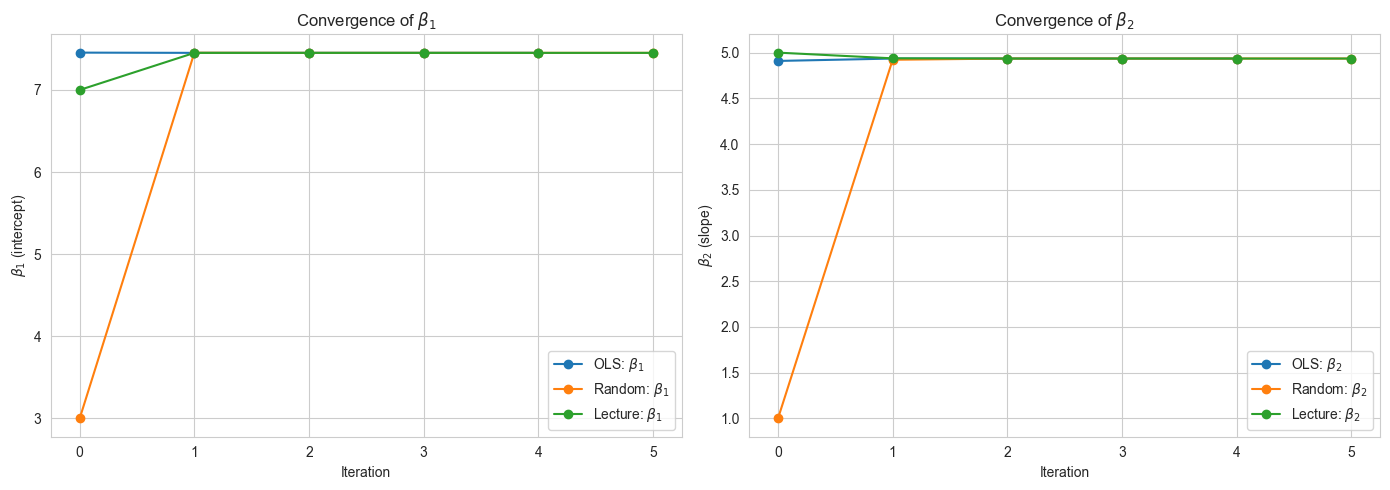

In [10]:
# Convergence plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, label in [(history_ols, 'OLS'), (history_random, 'Random'), (history_lecture, 'Lecture')]:
    axes[0].plot(hist[:, 0], 'o-', label=f'{label}: $\\beta_1$')
    axes[1].plot(hist[:, 1], 'o-', label=f'{label}: $\\beta_2$')

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('$\\beta_1$ (intercept)')
axes[0].set_title('Convergence of $\\beta_1$')
axes[0].legend()

axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('$\\beta_2$ (slope)')
axes[1].set_title('Convergence of $\\beta_2$')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Comparison with statsmodels
model_sm1 = sm.GLM(Y1, X1, family=Poisson(link=Identity()))
results_sm1 = model_sm1.fit()
print(results_sm1.summary())
print(f"\nOur IWLS estimate: {history_ols[-1]}")
print(f"statsmodels estimate: {results_sm1.params}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                    9
Model:                            GLM   Df Residuals:                        7
Model Family:                 Poisson   Df Model:                            1
Link Function:               Identity   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18.004
Date:                Sat, 21 Mar 2026   Deviance:                       1.8947
Time:                        16:17:54   Pearson chi2:                     1.89
No. Iterations:                     4   Pseudo R-squ. (CS):             0.8406
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.4516      0.884      8.428      0.0

---
# 6. Example 2: Poisson with Log Link (AIDS data, Dobson 4.1)

Example 4.1 from Dobson: Numbers of AIDS cases in Australia by date of diagnosis for successive 3-month periods from 1984 to 1988.

In [12]:
# Load AIDS data from GitHub

aids_data = "\\Users\\Ruslanidze\\ZLMA\\aids.csv"
aids = pd.read_csv(aids_data)
aids['time_index'] = np.arange(1, len(aids) + 1)
aids

,year,quarter,cases,time_index
0,1984,1,1,1
1,1984,2,6,2
2,1984,3,16,3
3,1984,4,23,4
4,1985,1,27,5
5,1985,2,39,6
6,1985,3,31,7
7,1985,4,30,8
8,1986,1,43,9
9,1986,2,51,10


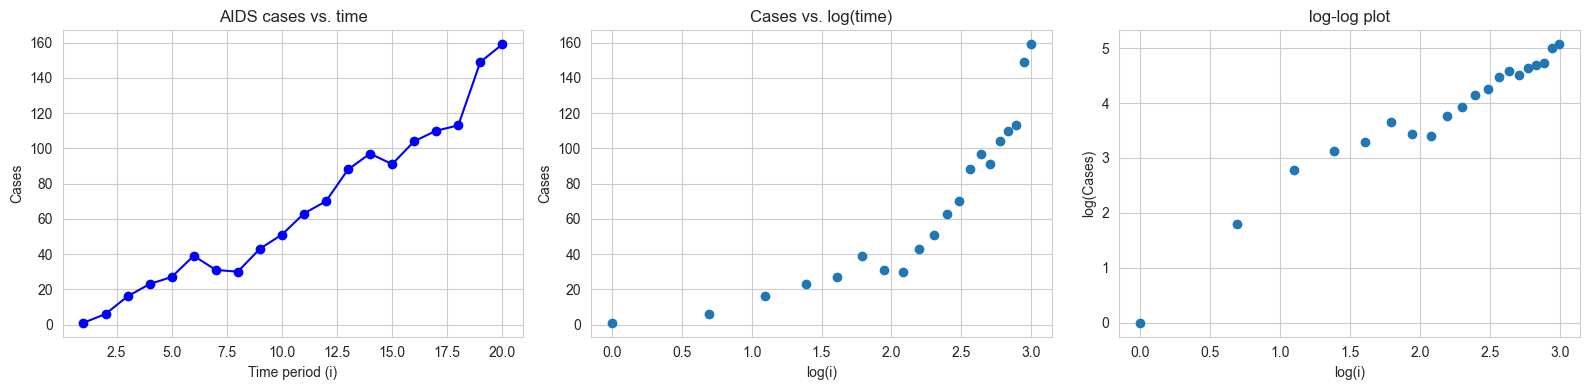

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Cases vs time
axes[0].plot(aids['time_index'], aids['cases'], 'bo-')
axes[0].set_xlabel('Time period (i)')
axes[0].set_ylabel('Cases')
axes[0].set_title('AIDS cases vs. time')

# log(cases) vs log(i)
axes[1].scatter(np.log(aids['time_index']), aids['cases'])
axes[1].set_xlabel('log(i)')
axes[1].set_ylabel('Cases')
axes[1].set_title('Cases vs. log(time)')

# log(cases) vs log(i)
axes[2].scatter(np.log(aids['time_index']), np.log(aids['cases']))
axes[2].set_xlabel('log(i)')
axes[2].set_ylabel('log(Cases)')
axes[2].set_title('log-log plot')

plt.tight_layout()
plt.show()

### Model specification

Assume $Y_i \sim \text{Poisson}(\lambda_i)$ with **log link**:
$$g(\lambda_i) = \ln(\lambda_i) = \beta_1 + \beta_2 x_i, \quad \text{where } x_i = \ln(i)$$

So $\mu_i = \lambda_i = \exp(\beta_1 + \beta_2 x_i)$ and $g'(\mu_i) = 1/\mu_i$.

**Weight matrix for Poisson with log link:**
$$w_{ii} = V[Y_i] \cdot g'(\mu_i)^2 = \mu_i \cdot (1/\mu_i)^2 = 1/\mu_i$$

So $W^{-1} = \text{diag}(\mu_i) = \text{diag}\big(e^{\mathbf{x}_i^T\boldsymbol{\beta}}\big)$.

**Working response for log link:**
$$z_i = \eta_i + g'(\mu_i)(y_i - \mu_i) = \mathbf{x}_i^T\boldsymbol{\beta} + \frac{y_i - \mu_i}{\mu_i}$$

**Note:** Log is the **canonical link** for Poisson, so NR $\equiv$ Fisher Scoring here.

In [14]:
# Setup
Y2 = aids['cases'].values.astype(float)
X2 = np.column_stack((np.ones(len(Y2)), np.log(aids['time_index'].values)))
n2 = len(Y2)

# Functions for Poisson log-link
def calc_mu_log(X, beta):
    """mu = exp(X @ beta)"""
    return np.exp(X @ beta)

def calc_W_inv_log(X, beta):
    """W_inv = diag(mu) for Poisson log-link"""
    mu = calc_mu_log(X, beta)
    return np.diag(mu)

def calc_Z_log(X, Y, beta):
    """Working response Z = eta + (y - mu)/mu for log-link"""
    eta = X @ beta
    mu = np.exp(eta)
    return eta + (Y - mu) / mu

def poisson_loglik(X, Y, beta):
    """Poisson log-likelihood"""
    mu = calc_mu_log(X, beta)
    return np.sum(Y * np.log(mu) - mu - gammaln(Y + 1))

### 6.1 IWLS Implementation

In [15]:
def IWLS_poisson_log(X, Y, beta_init, max_iter=100, tol=1e-8):
    """IWLS for Poisson GLM with log link"""
    beta = beta_init.copy()
    beta_history = [beta.copy()]
    ll_history = [poisson_loglik(X, Y, beta)]

    for i in range(max_iter):
        W_inv = calc_W_inv_log(X, beta)
        Z = calc_Z_log(X, Y, beta)
        beta_new = np.linalg.solve(X.T @ W_inv @ X, X.T @ W_inv @ Z)
        beta_history.append(beta_new.copy())
        ll_history.append(poisson_loglik(X, Y, beta_new))
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history), np.array(ll_history)

### 6.2 Fisher Scoring (direct computation)

For Poisson with log link $\ln\mu_i = \beta_1 + \beta_2 x_i$, where $\mu_i = e^{\beta_1 + \beta_2 x_i}$:

**Score vector:**
$$U_1 = \sum_{i=1}^n y_i - e^{\beta_1} \sum_{i=1}^n e^{\beta_2 x_i}, \qquad U_2 = \sum_{i=1}^n x_i y_i - e^{\beta_1} \sum_{i=1}^n x_i e^{\beta_2 x_i}$$

**Fisher information:**
$$I = e^{\beta_1} \begin{pmatrix} \sum e^{\beta_2 x_i} & \sum x_i e^{\beta_2 x_i} \\ \sum x_i e^{\beta_2 x_i} & \sum x_i^2 e^{\beta_2 x_i} \end{pmatrix}$$

In [16]:
def fisher_scoring_poisson_log(x, Y, beta_init, max_iter=100, tol=1e-8):
    """Fisher Scoring for Poisson log-link (direct computation from lecture)"""
    beta = beta_init.copy()
    beta_history = [beta.copy()]
    X_design = np.column_stack((np.ones(len(Y)), x))
    ll_history = [poisson_loglik(X_design, Y, beta)]

    for i in range(max_iter):
        pom = np.exp(beta[1] * x)
        # Fisher information matrix
        a11 = np.exp(beta[0]) * np.sum(pom)
        a12 = np.exp(beta[0]) * np.sum(x * pom)
        a22 = np.exp(beta[0]) * np.sum(x**2 * pom)
        FM = np.array([[a11, a12], [a12, a22]])
        # Score vector
        u1 = np.sum(Y) - np.exp(beta[0]) * np.sum(pom)
        u2 = np.sum(x * Y) - np.exp(beta[0]) * np.sum(x * pom)
        SV = np.array([u1, u2])
        # Update
        beta_new = beta + np.linalg.solve(FM, SV)
        beta_history.append(beta_new.copy())
        ll_history.append(poisson_loglik(X_design, Y, beta_new))
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history), np.array(ll_history)

### 6.3 Newton-Raphson Implementation

In [17]:
def newton_raphson_poisson_log(X, Y, beta_init, max_iter=100, tol=1e-8):
    """Newton-Raphson for Poisson log-link. For canonical link, NR = Fisher Scoring."""
    beta = beta_init.copy()
    beta_history = [beta.copy()]
    ll_history = [poisson_loglik(X, Y, beta)]

    for i in range(max_iter):
        mu = calc_mu_log(X, beta)
        # Score vector: U = X^T (y - mu)
        U = X.T @ (Y - mu)
        # Observed Hessian: H = -X^T diag(mu) X (for canonical link = -I)
        H = -X.T @ np.diag(mu) @ X
        # NR update: beta_new = beta - H^{-1} U
        beta_new = beta - np.linalg.solve(H, U)
        beta_history.append(beta_new.copy())
        ll_history.append(poisson_loglik(X, Y, beta_new))
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history), np.array(ll_history)

### 6.4 Run and compare all three methods

In [18]:
# Initial values: OLS on log(Y)
x_log = np.log(aids['time_index'].values)
beta_init2 = np.linalg.lstsq(X2, np.log(Y2), rcond=None)[0]
print(f"Initial beta (OLS on log(Y)): {beta_init2}")

# Run all three methods
hist_iwls, ll_iwls = IWLS_poisson_log(X2, Y2, beta_init2)
hist_fs, ll_fs = fisher_scoring_poisson_log(x_log, Y2, beta_init2)
hist_nr, ll_nr = newton_raphson_poisson_log(X2, Y2, beta_init2)

print(f"\nIWLS converged to {hist_iwls[-1]} in {len(hist_iwls)-1} iterations")
print(f"Fisher Scoring converged to {hist_fs[-1]} in {len(hist_fs)-1} iterations")
print(f"Newton-Raphson converged to {hist_nr[-1]} in {len(hist_nr)-1} iterations")

Initial beta (OLS on log(Y)): [0.685834 1.454341]

IWLS converged to [0.995998 1.32661 ] in 4 iterations
Fisher Scoring converged to [0.995998 1.32661 ] in 4 iterations
Newton-Raphson converged to [0.995998 1.32661 ] in 4 iterations


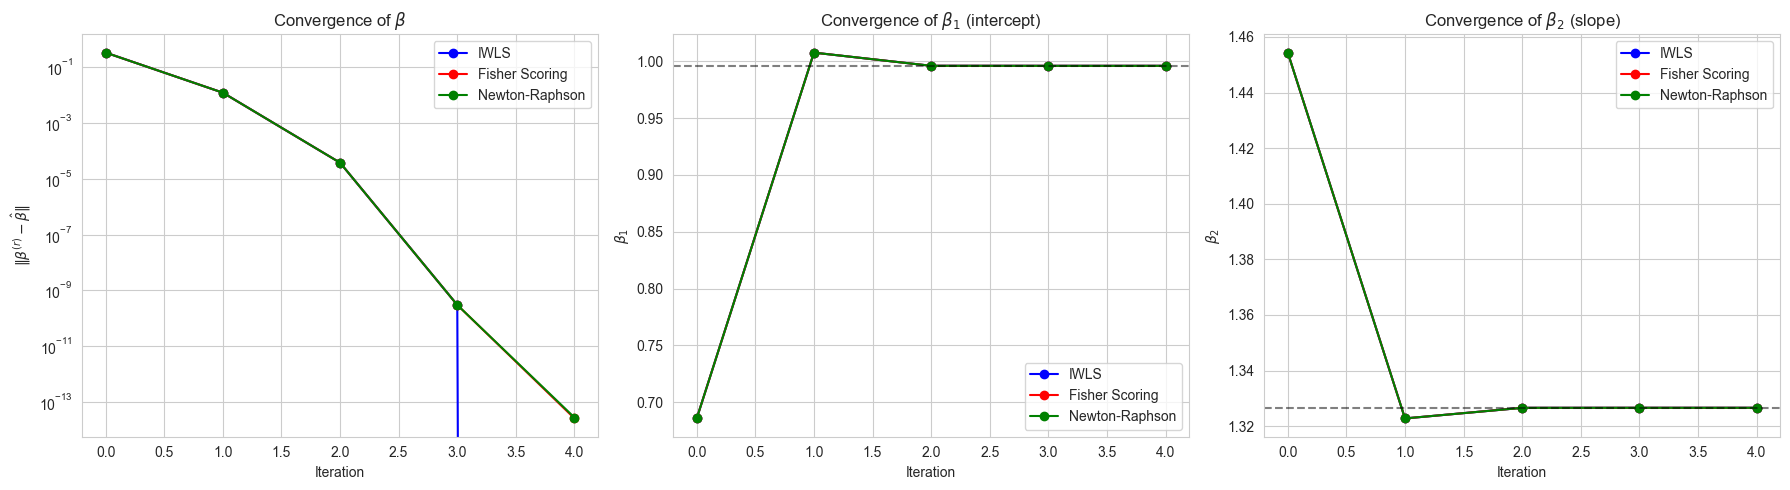

In [19]:
# Convergence comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Beta convergence
beta_final = hist_iwls[-1]
for hist, label, color in [(hist_iwls, 'IWLS', 'blue'), (hist_fs, 'Fisher Scoring', 'red'),
                            (hist_nr, 'Newton-Raphson', 'green')]:
    errors = np.sqrt(np.sum((hist - beta_final)**2, axis=1))
    axes[0].semilogy(errors, 'o-', label=label, color=color)

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('$\\|\\beta^{(r)} - \\hat{\\beta}\\|$')
axes[0].set_title('Convergence of $\\beta$')
axes[0].legend()

# Beta_1 convergence
for hist, label, color in [(hist_iwls, 'IWLS', 'blue'), (hist_fs, 'Fisher Scoring', 'red'),
                            (hist_nr, 'Newton-Raphson', 'green')]:
    axes[1].plot(hist[:, 0], 'o-', label=f'{label}', color=color)
axes[1].axhline(y=beta_final[0], color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('$\\beta_1$')
axes[1].set_title('Convergence of $\\beta_1$ (intercept)')
axes[1].legend()

# Beta_2 convergence
for hist, label, color in [(hist_iwls, 'IWLS', 'blue'), (hist_fs, 'Fisher Scoring', 'red'),
                            (hist_nr, 'Newton-Raphson', 'green')]:
    axes[2].plot(hist[:, 1], 'o-', label=f'{label}', color=color)
axes[2].axhline(y=beta_final[1], color='black', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('$\\beta_2$')
axes[2].set_title('Convergence of $\\beta_2$ (slope)')
axes[2].legend()

plt.tight_layout()
plt.show()

In [20]:
# Comparison with statsmodels
model_sm2 = sm.GLM(Y2, X2, family=Poisson(link=Log()))
results_sm2 = model_sm2.fit()
print(results_sm2.summary())
print(f"\nOur IWLS estimate: {hist_iwls[-1]}")
print(f"statsmodels estimate: {results_sm2.params}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   20
Model:                            GLM   Df Residuals:                       18
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67.027
Date:                Sat, 21 Mar 2026   Deviance:                       21.755
Time:                        16:17:55   Pearson chi2:                     21.7
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9960      0.170      5.869      0.0

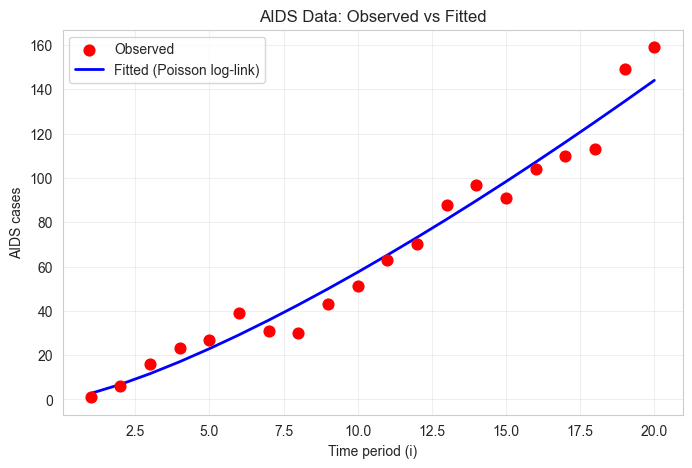

In [21]:
# Fitted values plot
mu_hat = np.exp(X2 @ results_sm2.params)
plt.figure(figsize=(8, 5))
plt.scatter(aids['time_index'], Y2, color='red', s=60, label='Observed', zorder=5)
plt.plot(aids['time_index'], mu_hat, 'b-', linewidth=2, label='Fitted (Poisson log-link)')
plt.xlabel('Time period (i)')
plt.ylabel('AIDS cases')
plt.title('AIDS Data: Observed vs Fitted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# 7. Example 3: Gamma Regression

**Gamma distribution in the exponential family:**
- $\theta = -1/\mu$, $b(\theta) = -\ln(-\theta) = \ln(\mu)$, $a(\phi) = 1/\nu$
- $v(\mu) = \mu^2$, canonical link$^*$: $g(\mu) = 1/\mu$ (reciprocal, see sign convention in Section 1.3)

**Weight matrix for Gamma with canonical (reciprocal) link:**
- $g'(\mu) = -1/\mu^2$, so $g'(\mu)^2 = 1/\mu^4$
- $w_{ii} = V[Y_i] \cdot g'(\mu_i)^2 = (\mu_i^2/\nu) \cdot (1/\mu_i^4) = 1/(\nu \mu_i^2)$
- For IWLS with known $\nu$: $W^{-1} = \nu \cdot \text{diag}(\mu_i^2)$

**Working response for reciprocal link:**
$$z_i = \frac{1}{\mu_i} + \left(-\frac{1}{\mu_i^2}\right)(y_i - \mu_i) = \frac{1}{\mu_i} - \frac{y_i - \mu_i}{\mu_i^2} = \frac{2}{\mu_i} - \frac{y_i}{\mu_i^2}$$

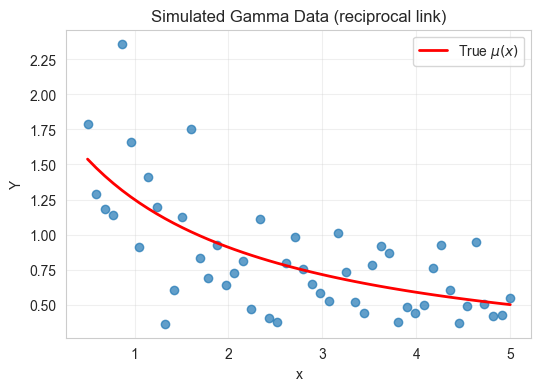

In [22]:
# Simulate Gamma data
np.random.seed(42)
n3 = 50
x3 = np.linspace(0.5, 5, n3)
X3 = np.column_stack((np.ones(n3), x3))
beta_true3 = np.array([0.5, 0.3])  # true 1/mu = 0.5 + 0.3*x
mu_true3 = 1.0 / (X3 @ beta_true3)
nu = 5  # shape parameter
Y3 = np.random.gamma(shape=nu, scale=mu_true3 / nu, size=n3)

plt.figure(figsize=(6, 4))
plt.scatter(x3, Y3, alpha=0.7)
plt.plot(x3, mu_true3, 'r-', linewidth=2, label='True $\\mu(x)$')
plt.xlabel('x')
plt.ylabel('Y')
plt.title('Simulated Gamma Data (reciprocal link)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
def IWLS_gamma_reciprocal(X, Y, beta_init, max_iter=100, tol=1e-8):
    """IWLS for Gamma GLM with reciprocal (canonical) link: g(mu) = 1/mu"""
    beta = beta_init.copy()
    beta_history = [beta.copy()]

    for i in range(max_iter):
        eta = X @ beta
        mu = 1.0 / eta  # reciprocal link inverse: mu = 1/eta
        # W_inv for Gamma reciprocal link: diag(mu^2) (up to scale factor nu)
        W_inv = np.diag(mu**2)
        # Working response: z = 1/mu + (-1/mu^2)(y - mu) = 2/mu - y/mu^2
        Z = 2.0 / mu - Y / mu**2
        beta_new = np.linalg.solve(X.T @ W_inv @ X, X.T @ W_inv @ Z)
        beta_history.append(beta_new.copy())
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history)

# Initial values: OLS on 1/Y
beta_init3 = np.linalg.lstsq(X3, 1.0 / Y3, rcond=None)[0]
hist_gamma = IWLS_gamma_reciprocal(X3, Y3, beta_init3)

print(f"True beta: {beta_true3}")
print(f"IWLS estimate: {hist_gamma[-1]}")
print(f"Converged in {len(hist_gamma)-1} iterations")

True beta: [0.5 0.3]
IWLS estimate: [0.52635  0.295681]
Converged in 5 iterations


In [24]:
# Comparison with statsmodels
model_sm3 = sm.GLM(Y3, X3, family=Gamma(link=InversePower()))
results_sm3 = model_sm3.fit()
print(results_sm3.summary())
print(f"\nOur IWLS: {hist_gamma[-1]}")
print(f"statsmodels: {results_sm3.params}")
print(f"True: {beta_true3}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   50
Model:                            GLM   Df Residuals:                       48
Model Family:                   Gamma   Df Model:                            1
Link Function:           InversePower   Scale:                         0.12386
Method:                          IRLS   Log-Likelihood:                -3.3043
Date:                Sat, 21 Mar 2026   Deviance:                       6.0343
Time:                        16:17:55   Pearson chi2:                     5.95
No. Iterations:                     6   Pseudo R-squ. (CS):             0.5566
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5263      0.108      4.895      0.0

---
# 8. Example 4: Bernoulli / Logistic Regression (preview)

**Bernoulli with logit (canonical) link:**
- $g(\mu) = \ln\frac{\mu}{1-\mu}$ (logit), $g'(\mu) = \frac{1}{\mu(1-\mu)}$
- $v(\mu) = \mu(1-\mu)$
- $w_{ii} = v(\mu_i) \cdot g'(\mu_i)^2 = \mu_i(1-\mu_i) \cdot \frac{1}{[\mu_i(1-\mu_i)]^2} = \frac{1}{\mu_i(1-\mu_i)}$
- $W^{-1} = \text{diag}(\mu_i(1-\mu_i))$

**Working response for logit link:**
$$z_i = \ln\frac{\mu_i}{1-\mu_i} + \frac{y_i - \mu_i}{\mu_i(1-\mu_i)}$$

In [25]:
# Simulate logistic regression data
np.random.seed(123)
n4 = 100
x4 = np.random.randn(n4)
X4 = np.column_stack((np.ones(n4), x4))
beta_true4 = np.array([0.5, 1.5])
eta4 = X4 @ beta_true4
mu4 = 1.0 / (1.0 + np.exp(-eta4))  # logistic function
Y4 = np.random.binomial(1, mu4)

In [26]:
def IWLS_logistic(X, Y, beta_init, max_iter=100, tol=1e-8):
    """IWLS for Bernoulli GLM with logit (canonical) link"""
    beta = beta_init.copy()
    beta_history = [beta.copy()]

    for i in range(max_iter):
        eta = X @ beta
        mu = 1.0 / (1.0 + np.exp(-eta))  # logistic function
        # W_inv = diag(mu*(1-mu))
        W_inv = np.diag(mu * (1 - mu))
        # Working response: z = logit(mu) + (y - mu)/(mu*(1-mu))
        Z = eta + (Y - mu) / (mu * (1 - mu))
        beta_new = np.linalg.solve(X.T @ W_inv @ X, X.T @ W_inv @ Z)
        beta_history.append(beta_new.copy())
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history)

# Initial values
beta_init4 = np.array([0.0, 0.0])
hist_logistic = IWLS_logistic(X4, Y4, beta_init4)

print(f"True beta: {beta_true4}")
print(f"IWLS estimate: {hist_logistic[-1]}")
print(f"Converged in {len(hist_logistic)-1} iterations")

True beta: [0.5 1.5]
IWLS estimate: [0.399119 1.727812]
Converged in 6 iterations


In [27]:
# Comparison with statsmodels
model_sm4 = sm.GLM(Y4, X4, family=Binomial(link=Logit()))
results_sm4 = model_sm4.fit()
print(results_sm4.summary())
print(f"\nOur IWLS: {hist_logistic[-1]}")
print(f"statsmodels: {results_sm4.params}")
print(f"True: {beta_true4}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -44.858
Date:                Sat, 21 Mar 2026   Deviance:                       89.716
Time:                        16:17:56   Pearson chi2:                     97.3
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3779
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3991      0.270      1.478      0.1

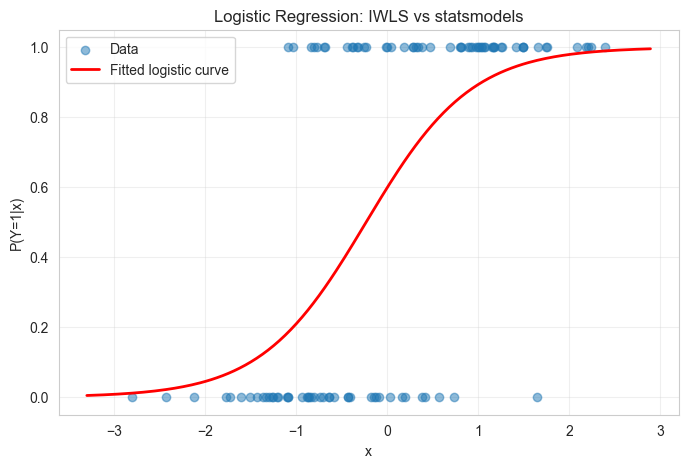

In [28]:
# Plot fitted logistic curve
x_plot = np.linspace(x4.min() - 0.5, x4.max() + 0.5, 200)
eta_plot = results_sm4.params[0] + results_sm4.params[1] * x_plot
mu_plot = 1.0 / (1.0 + np.exp(-eta_plot))

plt.figure(figsize=(8, 5))
plt.scatter(x4, Y4, alpha=0.5, label='Data')
plt.plot(x_plot, mu_plot, 'r-', linewidth=2, label='Fitted logistic curve')
plt.xlabel('x')
plt.ylabel('P(Y=1|x)')
plt.title('Logistic Regression: IWLS vs statsmodels')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# 9. Dispersion Parameter Estimation

If $a_i(\phi) = a_i \phi$, the **Pearson estimate** of the dispersion parameter is:

$$\tilde{\phi} = \frac{1}{n-p} \sum_{i=1}^n \frac{(y_i - \hat{\mu}_i)^2}{a_i \cdot v(\hat{\mu}_i)}$$

where $\hat{\mu}_i = g^{-1}(\mathbf{x}_i^T \hat{\boldsymbol{\beta}})$.

For **Poisson**: $\phi = 1$, $v(\mu) = \mu$, $a_i = 1$, so:
$$\tilde{\phi} = \frac{1}{n-p} \sum_{i=1}^n \frac{(y_i - \hat{\mu}_i)^2}{\hat{\mu}_i} = \frac{\text{Pearson } \chi^2}{n-p}$$

If $\tilde{\phi} \approx 1$: the Poisson model fits well. If $\tilde{\phi} \gg 1$: **overdispersion** — consider quasi-Poisson or Negative Binomial.

In [29]:
# Pearson estimate for Example 2 (AIDS data, Poisson log-link)
mu_hat2 = np.exp(X2 @ results_sm2.params)
pearson_chi2 = np.sum((Y2 - mu_hat2)**2 / mu_hat2)
p2 = X2.shape[1]  # number of parameters
phi_hat = pearson_chi2 / (n2 - p2)

print(f"Pearson chi-squared: {pearson_chi2:.4f}")
print(f"Pearson estimate of phi: {phi_hat:.4f}")
print(f"Expected phi for Poisson: 1.0")
print(f"Conclusion: {'Good fit' if 0.5 < phi_hat < 1.5 else 'Possible overdispersion' if phi_hat > 1.5 else 'Possible underdispersion'}")

# Verify with statsmodels
print(f"\nstatsmodels Pearson chi2: {results_sm2.pearson_chi2:.4f}")
print(f"statsmodels scale (phi): {results_sm2.pearson_chi2 / results_sm2.df_resid:.4f}")

Pearson chi-squared: 21.6657
Pearson estimate of phi: 1.2037
Expected phi for Poisson: 1.0
Conclusion: Good fit

statsmodels Pearson chi2: 21.6657
statsmodels scale (phi): 1.2037


---
# 10. Summary: Comparison of Methods & Distributions

### Comparison of Numerical Methods

| Method | Update formula&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Convergence | NR ≡ FS? |
|:---|:---|:---:|:---:|
| Newton-Raphson | $\beta^{(r+1)} = \beta^{(r)} - H^{-1} U$ | Quadratic | - |
| Fisher Scoring | $\beta^{(r+1)} = \beta^{(r)} + I^{-1} U$ | Linear | Yes (canonical link) |
| IWLS | $\beta^{(r+1)} = (X^TW^{-1}X)^{-1}X^TW^{-1}Z$ | Linear | Equivalent to FS |


### IWLS Components by Distribution and Link

| Distribution | Link $g(\mu)$ | $W^{-1} = \text{diag}(\ldots)$ | $z_i = \ldots$ |
|:---|:---|:---|:---|
| Poisson | identity | $\text{diag}(1/\mu_i)$ | $y_i$ |
| Poisson | log (canonical) | $\text{diag}(\mu_i)$ | $\eta_i + (y_i-\mu_i)/\mu_i$ |
| Bernoulli | logit (canonical) | $\text{diag}(\mu_i(1-\mu_i))$ | $\eta_i + (y_i-\mu_i)/[\mu_i(1-\mu_i)]$ |
| Gamma | reciprocal (canonical$^*$) | $\text{diag}(\nu\mu_i^2)$ | $2/\mu_i - y_i/\mu_i^2$ |
| Normal | identity (canonical) | $\text{diag}(1)$ | $y_i$ |

$^*$ See the sign convention note in Section 1.3. The factor $\nu$ in the Gamma $W^{-1}$ cancels in the IWLS update formula (it appears in both sides), so in practice it can be omitted without affecting the $\hat{\boldsymbol{\beta}}$ estimate.

---
# 11. Homework

1. Implement Newton-Raphson, Fisher Scoring, and IWLS for **Example 1** (Poisson identity link). Compare convergence of all three methods.

2. Try different initial values for Example 2 (AIDS data). How sensitive are the methods to initialization?

3. Implement stochastic gradient descent (SGD) for the Poisson log-link model and compare convergence with IWLS.

In [30]:
def expect(beta, X):
    return X @ beta

def g_prime(mu):
    return 1

def variance(mu):
    return mu

def weights(mu):
    return np.diag(1 / mu)

def working_response(mu, y, eta):
    return y

def Score_U(beta, X, y):
    mu = expect(beta, X)
    return np.transpose(X) @ np.diag(1/mu) @ (y - mu)

def Hessian_H(beta, X, y):
    mu = expect(beta, X)
    return -np.transpose(X) @ np.diag(1/mu) @ X

def Fisher_I(beta, X, y):
    mu = expect(beta, X)
    return np.transpose(X) @ np.diag(1/mu) @ X

def Newton_Raphson(X, y, beta_init, max_iter=1000, tol=1e-5):
    beta = beta_init.copy()
    history = [beta.copy()]

    for i in range(max_iter):
        U = Score_U(beta, X, y)
        H = Hessian_H(beta, X, y)
        beta_new = beta - np.linalg.solve(H, U)
        history.append(beta_new.copy())

        if np.linalg.norm(beta_new - beta) < tol:

            return history

        beta = beta_new

    return history

def Fisher_Score(X, y, beta_init, max_iter=1000, tol=1e-5):
    beta = beta_init.copy()
    history = [beta.copy()]

    for i in range(max_iter):
        U = Score_U(beta, X, y)
        I = Fisher_I(beta, X, y)
        beta_new = beta + np.linalg.solve(I, U)
        history.append(beta_new.copy())

        if np.linalg.norm(beta_new - beta) < tol:

            return history

        beta = beta_new

    return history

def IWLS(X, y, beta_init, max_iter=1000, tol=1e-5):
    beta = beta_init.copy()
    history = [beta.copy()]

    for i in range(max_iter):
        mu = expect(beta, X)
        U = Score_U(beta, X, y)
        I = Fisher_I(beta, X, y)
        W_inv = np.diag(1/mu)
        Z = y
        beta_new = np.linalg.solve(X.T @ W_inv @ X, X.T @ W_inv @ Z)

        history.append(beta_new.copy())

        if np.linalg.norm(beta_new - beta) < tol:

            return history

        beta = beta_new

    return history

In [31]:
x_raw = np.array([-1, -1, 0, 0, 0, 0, 1, 1, 1])
Y1 = np.array([2, 3, 6, 7, 8, 9, 10, 12, 15])
n1 = len(x_raw)

X1 = np.column_stack([np.ones(n1), x_raw])

beta_init = np.linalg.solve(X1.T @ X1, X1.T @ Y1)

hist_NR   = Newton_Raphson(X1, Y1, beta_init)
hist_FS   = Fisher_Score(X1, Y1, beta_init)
hist_IWLS = IWLS(X1, Y1, beta_init)

print("Newton-Raphson:")
for i, beta in enumerate(hist_NR):
    print(f"  iter {i}: β1 = {beta[0]:.6f}, β2 = {beta[1]:.6f}")

print("\nFisher Scoring:")
for i, beta in enumerate(hist_FS):
    print(f"  iter {i}: β1 = {beta[0]:.6f}, β2 = {beta[1]:.6f}")

print("\nIWLS:")
for i, beta in enumerate(hist_IWLS):
    print(f"  iter {i}: β1 = {beta[0]:.6f}, β2 = {beta[1]:.6f}")



Newton-Raphson:
  iter 0: β1 = 7.454545, β2 = 4.909091
  iter 1: β1 = 7.451651, β2 = 4.935142
  iter 2: β1 = 7.451633, β2 = 4.935299
  iter 3: β1 = 7.451633, β2 = 4.935300

Fisher Scoring:
  iter 0: β1 = 7.454545, β2 = 4.909091
  iter 1: β1 = 7.451651, β2 = 4.935142
  iter 2: β1 = 7.451633, β2 = 4.935299
  iter 3: β1 = 7.451633, β2 = 4.935300

IWLS:
  iter 0: β1 = 7.454545, β2 = 4.909091
  iter 1: β1 = 7.451651, β2 = 4.935142
  iter 2: β1 = 7.451633, β2 = 4.935299
  iter 3: β1 = 7.451633, β2 = 4.935300


In [32]:
# Log link:
def Score_U_log(beta, X, y):
    mu = np.exp(X @ beta)  
    return X.T @ (y - mu)  

def Fisher_I_log(beta, X, y):
    mu = np.exp(X @ beta)
    return X.T @ np.diag(mu) @ X 

def Hessian_H_log(beta, X, y):
    return -Fisher_I_log(beta, X, y)


def Newton_Raphson(X, y, beta_init, max_iter=1000, tol=1e-10):
    beta = beta_init.copy()
    history = [beta.copy()]

    for i in range(max_iter):
        U = Score_U_log(beta, X, y)
        H = Hessian_H_log(beta, X, y)
        beta_new = beta - np.linalg.solve(H, U)
        history.append(beta_new.copy())

        if np.linalg.norm(beta_new - beta) < tol:

            return history

        beta = beta_new

    return history

def Fisher_Score(X, y, beta_init, max_iter=1000, tol=1e-10):
    beta = beta_init.copy()
    history = [beta.copy()]

    for i in range(max_iter):
        U = Score_U_log(beta, X, y)
        I = Fisher_I_log(beta, X, y)
        beta_new = beta + np.linalg.solve(I, U)
        history.append(beta_new.copy())

        if np.linalg.norm(beta_new - beta) < tol:

            return history

        beta = beta_new

    return history

def IWLS(X, y, beta_init, max_iter=1000, tol=1e-10):
    beta = beta_init.copy()
    history = [beta.copy()]


    for i in range(max_iter):
        mu = np.exp(X @ beta) 
        eta = X @ beta
        U = Score_U_log(beta, X, y)
        I = Fisher_I_log(beta, X, y)
        W_inv = np.diag(mu)
        Z = eta + (y - mu) / mu 
        beta_new = np.linalg.solve(X.T @ W_inv @ X, X.T @ W_inv @ Z)

        history.append(beta_new.copy())

        if np.linalg.norm(beta_new - beta) < tol:

            return history

        beta = beta_new

    return history

In [ ]:
aids['time_index'] = np.arange(1, len(aids) + 1)

y2 = aids['cases'].values.astype(float)
x2 = np.log(aids['time_index'].values)
X2 = np.column_stack([np.ones(len(y2)), x2])



# Initial values for sensitivity analysis (Homework Q2)
beta_ols  = np.linalg.lstsq(X2, np.log(y2 + 1), rcond=None)[0]
inits = {
    'OLS on log(y)': beta_ols,
    'Zero':          np.zeros(2),
    'Near true':     np.array([1.0, 1.3]),
    'Far':           np.array([5.0, -2.0]),
}

for name, beta_init in inits.items():
    hist_NR  = Newton_Raphson(X2, y2, beta_init)
    hist_FS  = Fisher_Score(X2, y2, beta_init)
    hist_IW  = IWLS(X2, y2, beta_init)

    print(f"\n--- {name}: {beta_init} ---")

    print(f"  NR ({len(hist_NR)-1} iterací): {hist_NR[-1]}")
    print(f"  FS ({len(hist_FS)-1} iterací): {hist_FS[-1]}")
    print(f"  IWLS ({len(hist_IW)-1} iterací): {hist_IW[-1]}")


[0.       0.693147 1.098612 1.386294 1.609438 1.791759 1.94591  2.079442
 2.197225 2.302585 2.397895 2.484907 2.564949 2.639057 2.70805  2.772589
 2.833213 2.890372 2.944439 2.995732]

--- OLS on log(y): [1.042148 1.314875] ---
  NR (4 iterací): [0.995998 1.32661 ]
  FS (4 iterací): [0.995998 1.32661 ]
  IWLS (4 iterací): [0.995998 1.32661 ]

--- Zero: [0. 0.] ---
  NR (108 iterací): [0.995998 1.32661 ]
  FS (108 iterací): [0.995998 1.32661 ]
  IWLS (108 iterací): [0.995998 1.32661 ]

--- Near true: [1.  1.3] ---
  NR (4 iterací): [0.995998 1.32661 ]
  FS (4 iterací): [0.995998 1.32661 ]
  IWLS (4 iterací): [0.995998 1.32661 ]

--- Far: [ 5. -2.] ---
  NR (63 iterací): [0.995998 1.32661 ]
  FS (63 iterací): [0.995998 1.32661 ]
  IWLS (63 iterací): [0.995998 1.32661 ]


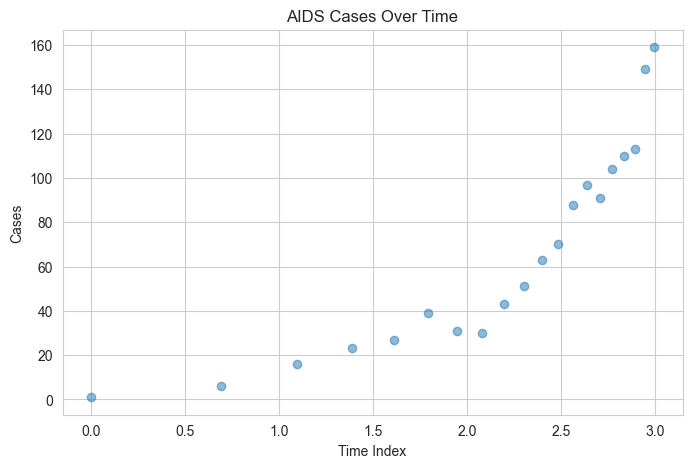

In [56]:
i = aids['time_index']
y = aids['cases']

plt.figure(figsize=(8, 5))
plt.scatter(np.log(i), y, alpha=0.5)
plt.xlabel('Time Index')
plt.ylabel('Cases')
plt.title('AIDS Cases Over Time')
plt.show()

In [51]:
def GD(X, y, beta_init, alpha=0.0001, max_iter=10000):
    beta = beta_init.copy()
    history = [beta.copy()]
    for t in range(max_iter):
        mu = np.exp(np.clip(X @ beta, -50, 50))
        U = X.T @ (y - mu)
        beta = beta + alpha * U
        history.append(beta.copy())
    return history


def SGD(X, y, beta_init, alpha=0.001, max_iter=50000):
    beta = beta_init.copy()
    history = [beta.copy()]
    n = len(y)

    for _ in range(max_iter):
        i = np.random.randint(n)       
        mu_i = np.exp(np.clip(X[i] @ beta, -50, 50))       
        U_i = X[i] * (y[i] - mu_i)     
        alpha_t = alpha / (1 + _ / 200.0)
        beta = beta + alpha_t * U_i
        if _ % 100 == 0:
            history.append(beta.copy()) 

    history.append(beta.copy())
    return history

def SGD_momentum(X, y, beta_init, alpha=0.001, gamma=0.5, max_iter=50000, clip=2.0):
    beta = beta_init.copy()
    v = np.zeros_like(beta)    
    history = [beta.copy()]
    n = len(y)

    for _ in range(max_iter):
        i = np.random.randint(n)
        mu_i = np.exp(np.clip(X[i] @ beta, -50, 50))
        U_i = X[i] * (y[i] - mu_i)
        grad_norm = np.linalg.norm(U_i)
        if grad_norm > clip:
            U_i = U_i * (clip / grad_norm)
        alpha_t = alpha / (1 + _ / 200.0)
        v = gamma * v + alpha_t * U_i    
        beta = beta + v                
        if _ % 100 == 0:
            history.append(beta.copy()) 

    history.append(beta.copy())
    return history

def SGD_nesterov(X, y, beta_init, alpha=0.001, gamma=0.5, max_iter=50000, clip=2.0):
    beta = beta_init.copy()
    v = np.zeros_like(beta)
    history = [beta.copy()]
    n = len(y)

    for _ in range(max_iter):
        i = np.random.randint(n)
        beta_ahead = beta + gamma * v
        mu_i = np.exp(np.clip(X[i] @ beta_ahead, -50, 50))
        U_i = X[i] * (y[i] - mu_i)
        grad_norm = np.linalg.norm(U_i)
        if grad_norm > clip:
            U_i = U_i * (clip / grad_norm)
        alpha_t = alpha / (1 + _ / 200.0)
        v = gamma * v + alpha_t * U_i
        beta = beta + v
        if _ % 100 == 0:
            history.append(beta.copy()) 
        
    history.append(beta.copy())
    return history

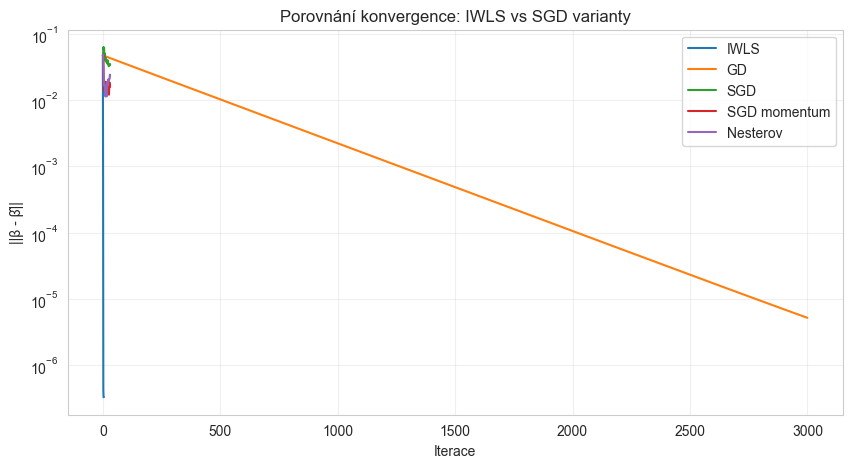

[0.995998 1.32661 ]
[0.996003 1.326608]
[1.029934 1.319867]
[0.980845 1.320664]
[0.973565 1.321302]


In [52]:
beta_true = np.array([0.995998, 1.32661])

# Proper initial values for log-link model (AIDS data)
beta_init2 = np.linalg.lstsq(X2, np.log(y2 + 1), rcond=None)[0]

hist_IW  = IWLS(X2, y2, beta_init2)
hist_GD = GD(X2, y2, beta_init2, alpha=0.0001, max_iter=3000)
hist_SGD = SGD(X2, y2, beta_init2, alpha=0.001, max_iter=3000)
hist_MOM = SGD_momentum(X2, y2, beta_init2, alpha=0.001, max_iter=3000)
hist_NES = SGD_nesterov(X2, y2, beta_init2, alpha=0.001, max_iter=3000)

def convergence_plot(histories, names, beta_true):
    plt.figure(figsize=(10, 5))
    for hist, name in zip(histories, names):
        errors = [np.linalg.norm(b - beta_true) for b in hist]
        plt.plot(errors, label=name)

    plt.xlabel("Iterace")
    plt.ylabel("||β - β̂||")
    plt.yscale("log")
    plt.legend()
    plt.title("Porovnání konvergence: IWLS vs SGD varianty")
    plt.grid(True, alpha=0.3)
    plt.show()

convergence_plot(
    [hist_IW, hist_GD, hist_SGD, hist_MOM, hist_NES],
    ["IWLS", "GD", "SGD", "SGD momentum", "Nesterov"],
    beta_true
)
print(hist_IW[-1])
print(hist_GD[-1])
print(hist_SGD[-1])
print(hist_MOM[-1])
print(hist_NES[-1])